# 03 — Exploratory Data Analysis
### "We know how to ask the database questions (Phase 2 SQL). Now let's bring the data into Python so we can investigate it more deeply."**

From here on, we query the **database** (already clean — see `sql/02_data_quality.sql`) instead of the raw CSV. This is the SQL -> pandas bridge: SQL retrieves and joins data close to the database; pandas continues the analysis once the data is small enough to live in memory.

We do **not** start with "let's make some charts." We start with a question, and only build a chart once we know what decision it needs to inform. Every analysis in this notebook follows:

**Question -> Metric -> Data -> Transformation -> Analysis -> Visualization -> Insight -> Business implication**

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from extract_data import load_sales_data
from utils import (
    add_time_features, apply_chart_style,
    CATEGORY_COLORS, WEEKEND_COLORS, SIZE_COLORS, SIZE_ORDER,
    WEEKDAY_ORDER, MONTH_ORDER,
)

%matplotlib inline
apply_chart_style()
pd.set_option('display.max_columns', 30)

## Extract & prepare

`load_sales_data()` runs the same 4-table JOIN taught in `sql/05_joins.sql`.
We then reuse `add_time_features()` — the exact same function `src/clean_data.py`
used in Notebook 02 — so "what counts as a weekend" or "what hour range is
Dinner" is defined **once**, not re-invented per notebook.

In [2]:
sales = load_sales_data()
sales = add_time_features(sales, date_col='order_date', time_col='order_time')
print(sales.shape)
sales.head(3)

20:21:32 | INFO    | Extracting full sales fact (order_details JOIN orders JOIN pizzas JOIN pizza_types)...


20:21:33 | INFO    | Extracted 48,620 rows, 13 columns.


(48620, 18)


,order_details_id,order_id,order_date,order_time,pizza_name_id,pizza_type_id,pizza_name,pizza_category,ingredients,pizza_size,unit_price,quantity,total_price,order_month,order_day_name,is_weekend,order_hour,time_of_day
0,1,1,2015-01-01,11:38:36,hawaiian_m,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",M,13.25,1,13.25,January,Thursday,False,11,Lunch
1,2,2,2015-01-01,11:57:40,classic_dlx_m,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",M,16.00,1,16.00,January,Thursday,False,11,Lunch
2,3,2,2015-01-01,11:57:40,five_cheese_l,five_cheese,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",L,18.50,1,18.50,January,Thursday,False,11,Lunch


---
## Theme 1: Sales Performance

**Question:** What is total revenue, how many orders, and how has revenue trended across the year?
**Metric:** `SUM(total_price)`, `COUNT(DISTINCT order_id)`, monthly revenue.
**Data:** `sales` (already extracted above).
**Transformation:** group by `order_month`.
**Analysis:** compare month to month.
**Visualization:** line chart (the right form for a TREND over time — see `references/choosing-a-form.md`).

In [3]:
total_revenue = sales['total_price'].sum()
total_orders = sales['order_id'].nunique()
total_pizzas = sales['quantity'].sum()
avg_order_value = total_revenue / total_orders

print(f"Total revenue:      ${total_revenue:,.2f}")
print(f"Total orders:        {total_orders:,}")
print(f"Total pizzas sold:    {total_pizzas:,}")
print(f"Average order value: ${avg_order_value:,.2f}")

Total revenue:      $817,860.05
Total orders:        21,350
Total pizzas sold:    49,574
Average order value: $38.31


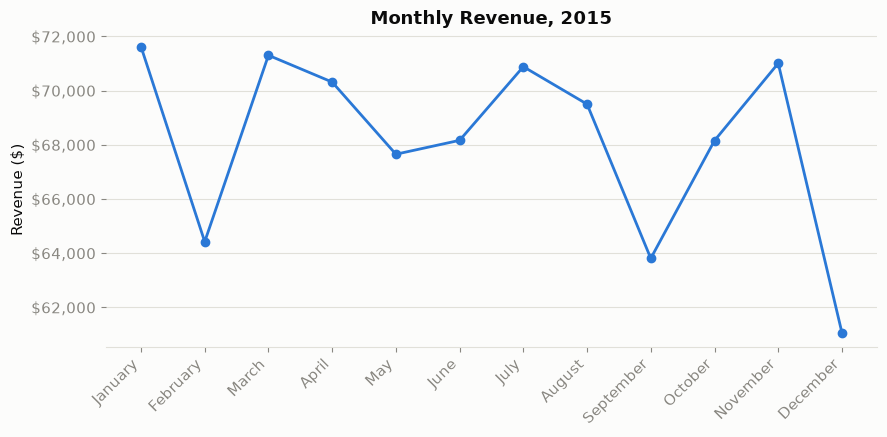

In [4]:
monthly_revenue = sales.groupby('order_month', observed=True)['total_price'].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color=CATEGORY_COLORS['Classic'], linewidth=2)
ax.set_title('Monthly Revenue, 2015')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** Revenue is remarkably stable across the year (roughly $61K-$72K/month, no single month is a dramatic outlier), with a mild dip in December and September. **Business implication:** this is NOT a strongly seasonal business at the monthly level — management should look for patterns at finer time grains (day of week, hour) rather than month, which the next sections do.

---
## Theme 2: Product Performance

**Question:** Which pizzas sell the most, and which generate the most revenue — are they the same pizzas?
**Visualization:** bar charts (the right form for COMPARISON across named categories).

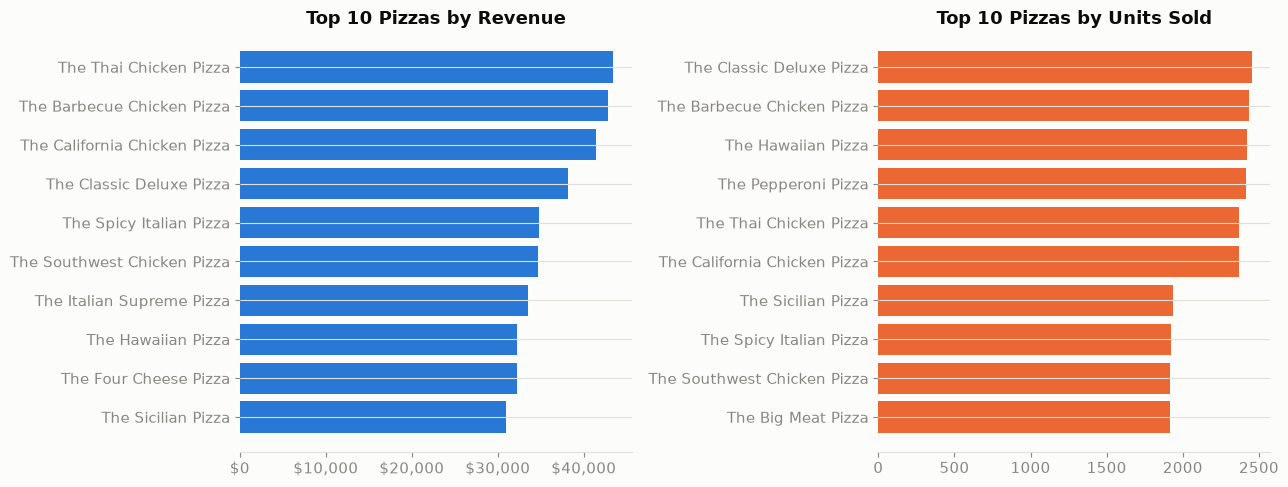

In [5]:
flavor_stats = (
    sales.groupby('pizza_name')
    .agg(units_sold=('quantity', 'sum'), revenue=('total_price', 'sum'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_revenue = flavor_stats.sort_values('revenue', ascending=False).head(10)
axes[0].barh(top_revenue['pizza_name'][::-1], top_revenue['revenue'][::-1], color=CATEGORY_COLORS['Classic'])
axes[0].set_title('Top 10 Pizzas by Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

top_units = flavor_stats.sort_values('units_sold', ascending=False).head(10)
axes[1].barh(top_units['pizza_name'][::-1], top_units['units_sold'][::-1], color=CATEGORY_COLORS['Chicken'])
axes[1].set_title('Top 10 Pizzas by Units Sold')

plt.tight_layout()
plt.show()

In [6]:
overlap = set(top_revenue['pizza_name']) & set(top_units['pizza_name'])
print(f"Pizzas in BOTH top-10 lists: {len(overlap)} of 10")
print(sorted(overlap))

Pizzas in BOTH top-10 lists: 8 of 10
['The Barbecue Chicken Pizza', 'The California Chicken Pizza', 'The Classic Deluxe Pizza', 'The Hawaiian Pizza', 'The Sicilian Pizza', 'The Southwest Chicken Pizza', 'The Spicy Italian Pizza', 'The Thai Chicken Pizza']


**Insight:** the two top-10 lists mostly, but not entirely, overlap — some pizzas sell in high volume without being top revenue earners (and vice versa), which is exactly Business Request 5 ("are there products that sell frequently but contribute little revenue?"). Notebook 04 investigates this directly.

**Relationship view:** plot every flavor's units sold against its revenue. A pizza that's high on the y-axis but not proportionally far right is selling a lot without earning proportionally as much — worth a second look.

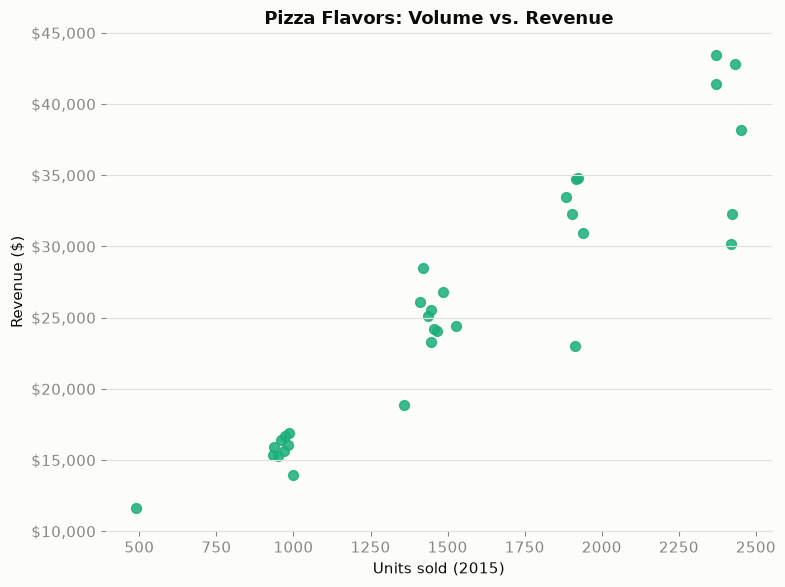

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(flavor_stats['units_sold'], flavor_stats['revenue'], color=CATEGORY_COLORS['Supreme'], s=50, alpha=0.85)
ax.set_xlabel('Units sold (2015)')
ax.set_ylabel('Revenue ($)')
ax.set_title('Pizza Flavors: Volume vs. Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## Theme 3: Time / Order Behavior

**Question:** When do customers order? Which hours and days are busiest?

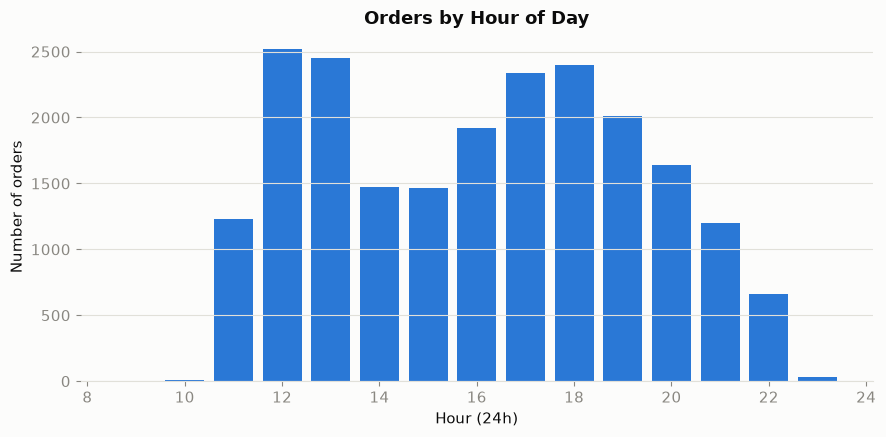

In [8]:
hourly = sales.groupby('order_hour')['order_id'].nunique()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(hourly.index, hourly.values, color=CATEGORY_COLORS['Classic'])
ax.set_title('Orders by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Number of orders')
plt.tight_layout()
plt.show()

**Insight:** two clear peaks — lunch (12:00-13:00) and dinner (18:00-19:00) — with a lull mid-afternoon. **Business implication:** staffing should follow this double-peak pattern rather than a flat schedule.

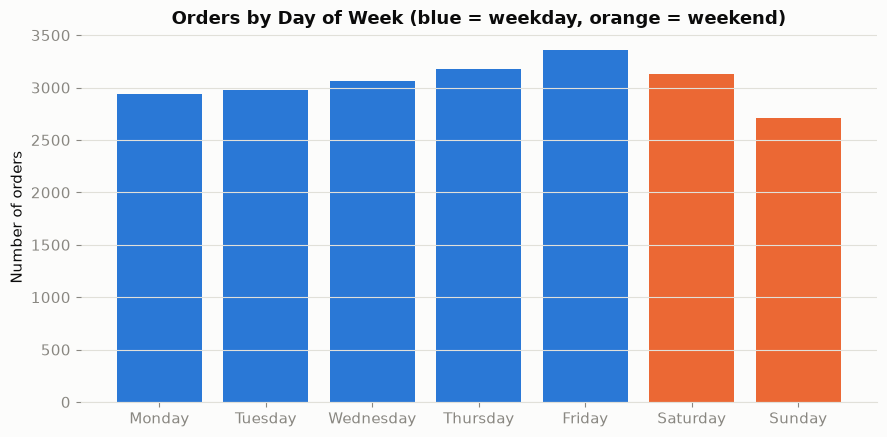

In [9]:
daily = sales.drop_duplicates('order_id').copy()
day_counts = daily.groupby('order_day_name', observed=True)['order_id'].nunique()
day_type = ['Weekend' if d in ('Saturday', 'Sunday') else 'Weekday' for d in day_counts.index]
colors = [WEEKEND_COLORS[t] for t in day_type]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(day_counts.index, day_counts.values, color=colors)
ax.set_title('Orders by Day of Week (blue = weekday, orange = weekend)')
ax.set_ylabel('Number of orders')
plt.tight_layout()
plt.show()

---
## Theme 4: Distribution — how large is a typical order?

**Question:** How much does order value vary? Are there outlier orders?
**Visualization:** histogram (shape of the distribution) + boxplot (spread and outliers by category).

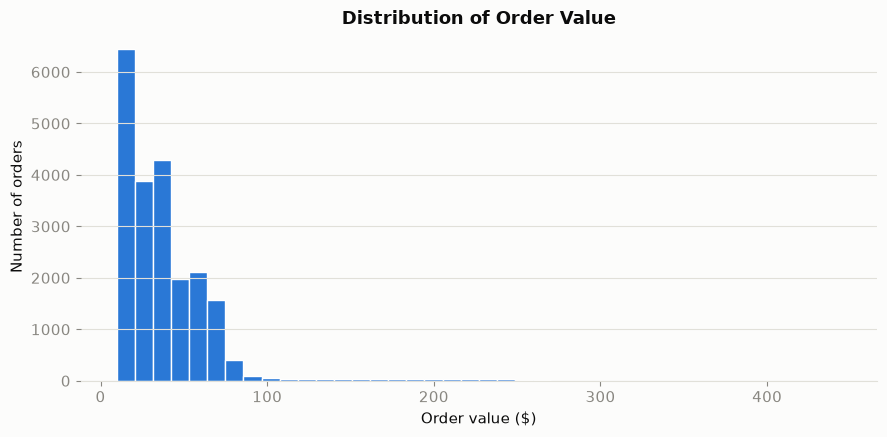

count    21350.000000
mean        38.307262
std         30.648197
min          9.750000
25%         17.950000
50%         32.500000
75%         49.500000
max        444.200000
Name: total_price, dtype: float64


In [10]:
order_values = sales.groupby('order_id')['total_price'].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(order_values, bins=40, color=CATEGORY_COLORS['Classic'], edgecolor='white')
ax.set_title('Distribution of Order Value')
ax.set_xlabel('Order value ($)')
ax.set_ylabel('Number of orders')
plt.tight_layout()
plt.show()

print(order_values.describe())

/tmp/ipykernel_520/467243209.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


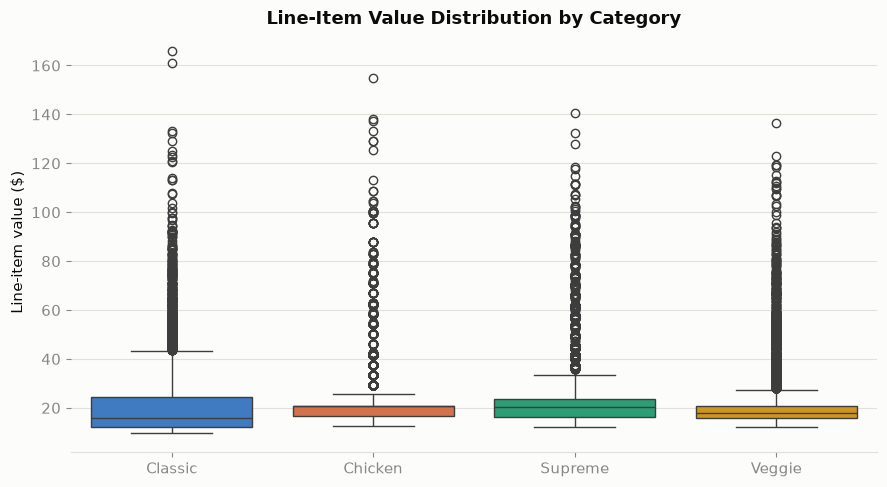

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
order_lines = sales.groupby(['order_id', 'pizza_category'], observed=True)['total_price'].sum().reset_index()
category_order = ['Classic', 'Chicken', 'Supreme', 'Veggie']
sns.boxplot(
    data=order_lines, x='pizza_category', y='total_price', order=category_order,
    palette=[CATEGORY_COLORS[c] for c in category_order], ax=ax,
)
ax.set_title('Line-Item Value Distribution by Category')
ax.set_xlabel('')
ax.set_ylabel('Line-item value ($)')
plt.tight_layout()
plt.show()

---
## Theme 5: Product Mix — composition by category over time

**Question:** Has any category been gaining or losing share of revenue across the year?
**Visualization:** stacked bar (the right form for COMPOSITION).

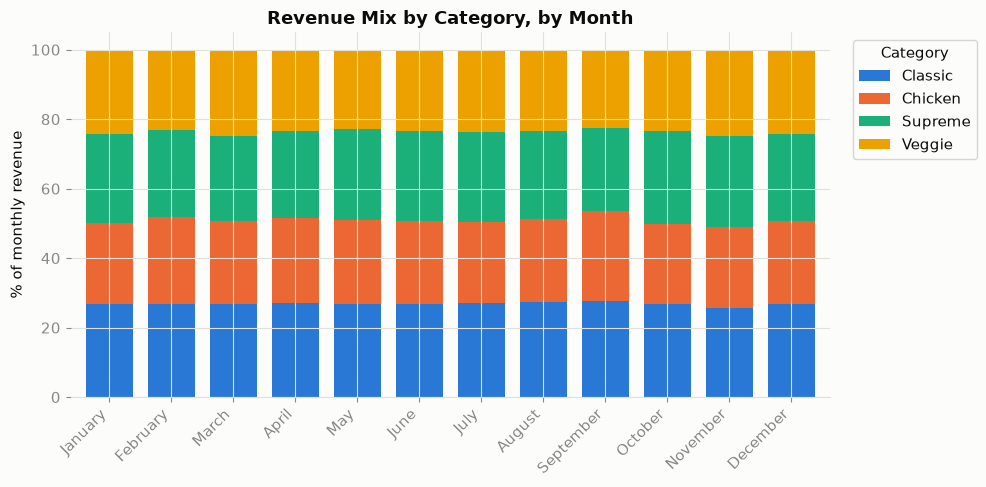

In [12]:
mix = sales.groupby(['order_month', 'pizza_category'], observed=True)['total_price'].sum().unstack('pizza_category')
mix = mix[category_order]
mix_share = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
mix_share.plot(kind='bar', stacked=True, ax=ax, color=[CATEGORY_COLORS[c] for c in category_order], width=0.75)
ax.set_title('Revenue Mix by Category, by Month')
ax.set_ylabel('% of monthly revenue')
ax.set_xlabel('')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:** category mix is stable month to month (each band stays roughly the same height throughout the year) — there's no evidence of a category gaining or losing share over 2015.

## Your Turn

Using the **Question -> Metric -> Data -> Transformation -> Analysis -> Visualization -> Insight -> Business implication** framework, answer one of these yourself (pick one, write out each step explicitly in markdown before you write any code):

1. Are large (L) pizzas actually more profitable per order than small (S) pizzas, or does that intuition not hold up in the data?
2. Is the lunch peak (Theme 3) driven more by weekday orders or weekend orders?
3. **Challenge:** Combine `time_of_day` and `pizza_category` — does the category mix shift between lunch and dinner?

In [13]:
# Your code here


## What we learned

- Revenue is stable month-to-month; the real time pattern is intraday (lunch/dinner peaks), not seasonal.
- Top-selling and top-revenue pizzas overlap but aren't identical — worth quantifying precisely.
- Order value is right-skewed with a clear typical range, and doesn't vary dramatically by category.
- Category mix is stable across the year.

**Next:** `04_business_analysis.ipynb` turns these findings into specific, evidence-based business recommendations — Business Request 6.